In [1]:
import zipfile
import pandas as pd
import numpy as np
import os

In [3]:
zip_path = "tdcsfog.zip"
extract_path = "tdcsfog_csvs"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

csv_files = [
    os.path.join(extract_path, f)
    for f in os.listdir(extract_path)
    if f.endswith(".csv")
]

print("Total CSV files:", len(csv_files))


Total CSV files: 833


In [4]:
fs = 128                  # sampling rate
window_size = 192         # 1.5 sec
step = 128                # 1 sec overlap

low_band  = (0.5, 2.8)
high_band = (2.8, 8)


In [5]:
def compute_fft(signal, fs):
    signal = signal - np.mean(signal)
    n = len(signal)
    fft_vals = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    power = np.abs(fft_vals) ** 2
    return freqs, power


def band_energy(freqs, power, band):
    idx = (freqs >= band[0]) & (freqs < band[1])
    return np.sum(power[idx])


In [6]:
def extract_features_from_df(df):
    features = []

    # ===== REQUIRED COLUMNS (ONCE) =====
    df["FOG"] = (
        (df["StartHesitation"] == 1) |
        (df["Turn"] == 1) |
        (df["Walking"] == 1)
    ).astype(int)

    df["Time_actual"] = np.arange(len(df)) / fs

    # ===== WINDOWING =====
    for start in range(0, len(df) - window_size, step):
        end = start + window_size
        win = df.iloc[start:end]

        fog_ratio = win["FOG"].mean()

        # label decision
        if fog_ratio >= 0.7:
            label = 1
        elif fog_ratio <= 0.3:
            label = 0
        else:
            continue   # ambiguous window drop

        row = {
            "label": label,
            "t_start": win["Time_actual"].iloc[0],
            "t_end":   win["Time_actual"].iloc[-1]
        }

        # ===== FEATURES =====
        for axis in ["AccV","AccML", "AccAP"]:
            signal = win[axis].values
            freqs, power = compute_fft(signal, fs)

            low_e  = band_energy(freqs, power, low_band)
            high_e = band_energy(freqs, power, high_band)
            ratio  = high_e / low_e if low_e > 0 else 0

            row[f"{axis}_lowE"]  = low_e
            row[f"{axis}_highE"] = high_e
            row[f"{axis}_ratio"] = ratio

        features.append(row)

    return pd.DataFrame(features)


In [7]:
all_features = []

for path in csv_files:
    df = pd.read_csv(path)

    feat_df = extract_features_from_df(df)

    subject_id = os.path.basename(path).replace(".csv", "")
    feat_df['subject_id'] = subject_id   # ✅ CSV name as subject

    all_features.append(feat_df)

final_df = pd.concat(all_features, ignore_index=True)


In [8]:
subjects = final_df['subject_id'].unique()

from sklearn.model_selection import train_test_split

train_subj, test_subj = train_test_split(
    subjects,
    test_size=0.20,
    random_state=42
)

train_df = final_df[final_df['subject_id'].isin(train_subj)].copy()
test_df  = final_df[final_df['subject_id'].isin(test_subj)].copy()


In [9]:
feature_cols = [c for c in train_df.columns if c not in ["label","t_start","t_end","subject_id"]]


In [10]:
print("Train class ratio:")
print(train_df['label'].value_counts(normalize=True))

print("\nTest class ratio:")
print(test_df['label'].value_counts(normalize=True))


Train class ratio:
label
0    0.717587
1    0.282413
Name: proportion, dtype: float64

Test class ratio:
label
0    0.593363
1    0.406637
Name: proportion, dtype: float64


In [11]:
from sklearn.preprocessing import RobustScaler, StandardScaler

X_train = train_df[feature_cols].values
y_train = train_df["label"].values

X_test  = test_df[feature_cols].values
y_test  = test_df["label"].values

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [12]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weights = compute_class_weight(
    'balanced',
    classes=classes,
    y=y_train  # ✅ y_train use karo (not train_df['label'])
)
class_weight_dict = dict(zip(classes, class_weights))

print("\nClass weights:", class_weight_dict)


Class weights: {np.int32(0): np.float64(0.6967800852330379), np.int32(1): np.float64(1.7704537641801306)}


In [13]:
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

print(np.median(X_train_scaled, axis=0)[:3])


(41202, 9) (41202,)
(11782, 9) (11782,)
[0. 0. 0.]


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(
    class_weight=class_weight_dict,  # ✅ Weights yahan use karo
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.76      0.83      6991
           1       0.72      0.90      0.80      4791

    accuracy                           0.81     11782
   macro avg       0.82      0.83      0.81     11782
weighted avg       0.83      0.81      0.82     11782


Confusion Matrix:
[[5283 1708]
 [ 484 4307]]


In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight=class_weight_dict,  # ✅ Weights yahan
    random_state=42,
    n_estimators=100
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.96      0.91      6991
           1       0.92      0.78      0.84      4791

    accuracy                           0.88     11782
   macro avg       0.89      0.87      0.88     11782
weighted avg       0.89      0.88      0.88     11782



In [34]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# SVM Model
svm_model = SVC(
    kernel='rbf',                    # Radial Basis Function (non-linear)
    C=1.0,                           # Regularization parameter
    gamma='scale',                   # Kernel coefficient
    #class_weight=class_weight_dict,  # ✅ Handle imbalance
    random_state=42,
    probability=True                 # Enable probability estimates
)

# Training
svm_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("=== SVM Results ===")
print(classification_report(y_test, y_pred_svm, target_names=['No FOG', 'FOG']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== SVM Results ===
              precision    recall  f1-score   support

      No FOG       0.76      0.98      0.85      6991
         FOG       0.94      0.54      0.69      4791

    accuracy                           0.80     11782
   macro avg       0.85      0.76      0.77     11782
weighted avg       0.83      0.80      0.78     11782


Confusion Matrix:
[[6826  165]
 [2203 2588]]


=== XGBoost Results ===
              precision    recall  f1-score   support

      No FOG       0.93      0.90      0.91      6991
         FOG       0.86      0.90      0.88      4791

    accuracy                           0.90     11782
   macro avg       0.89      0.90      0.89     11782
weighted avg       0.90      0.90      0.90     11782


Confusion Matrix:
[[6277  714]
 [ 497 4294]]


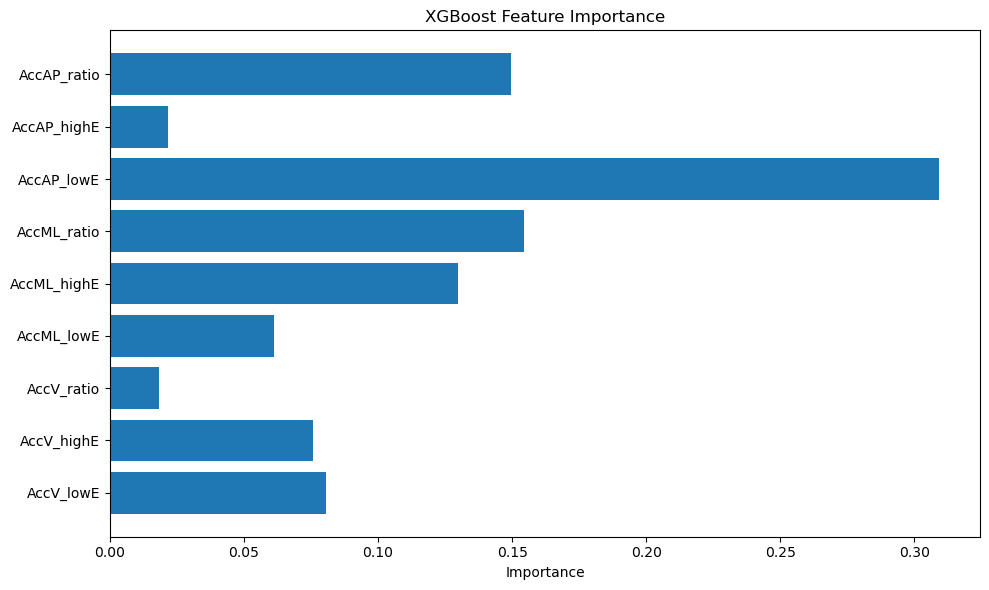

In [16]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Convert class weights for XGBoost
scale_pos_weight = class_weight_dict[1] / class_weight_dict[0]

# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=100,              # 100 decision trees
    max_depth=6,                   # Tree depth
    learning_rate=0.05,             # Step size for learning
    scale_pos_weight=scale_pos_weight,  # ✅ Handle imbalance
    random_state=42,
    eval_metric='logloss'
)

# Training
xgb_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluation
print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No FOG', 'FOG']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# # Feature Importance
import matplotlib.pyplot as plt

feature_importance = xgb_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_cols, feature_importance)
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


In [17]:
import pickle

# ===== SAVE MODEL =====
with open('fog_detection_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# ===== SAVE SCALER =====
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ===== SAVE FEATURE COLUMNS (IMPORTANT!) =====
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ Model, Scaler, and Feature Columns saved!")


✅ Model, Scaler, and Feature Columns saved!


In [33]:
import pandas as pd
import numpy as np
import pickle

# ===== LOAD SAVED OBJECTS =====
with open('fog_detection_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("✅ Model loaded successfully!")

# ===== LOAD NEW TEST CSV =====
new_test_file = "0bcd4db9cc.csv"  # Tumhara test CSV
new_df = pd.read_csv(new_test_file)

print(f"Loaded {len(new_df)} rows from test CSV")

# ===== EXTRACT FEATURES (SAME AS TRAINING) =====
# Use the SAME extract_features_from_df function
new_feat_df = extract_features_from_df(new_df)

print(f"Extracted {len(new_feat_df)} windows")

# ===== PREPARE DATA =====
X_new = new_feat_df[feature_cols].values

# ===== SCALE DATA (USING SAVED SCALER) =====
X_new_scaled = loaded_scaler.transform(X_new)

# ===== PREDICT =====
predictions = loaded_model.predict(X_new_scaled)
prediction_probs = loaded_model.predict_proba(X_new_scaled)[:, 1]  # Probability of FOG

# ===== ADD PREDICTIONS TO DATAFRAME =====
new_feat_df['predicted_label'] = predictions
new_feat_df['fog_probability'] = prediction_probs

print("\n✅ Predictions complete!")
print(f"FOG detected in {predictions.sum()} / {len(predictions)} windows")
print(f"FOG percentage: {predictions.mean()*100:.1f}%")



✅ Model loaded successfully!
Loaded 5854 rows from test CSV
Extracted 45 windows

✅ Predictions complete!
FOG detected in 2 / 45 windows
FOG percentage: 4.4%


In [30]:
def extract_fog_episodes(df):
    episodes = []
    in_episode = False

    for _, row in df.iterrows():
        if row['predicted_label'] == 1:
            if not in_episode:
                start_time = row['t_start']
                in_episode = True
            end_time = row['t_end']
        else:
            if in_episode:
                episodes.append({
                    "start_time": start_time,
                    "end_time": end_time,
                    "duration_sec": end_time - start_time
                })
                in_episode = False

    # handle case where FoG ends at last window
    if in_episode:
        episodes.append({
            "start_time": start_time,
            "end_time": end_time,
            "duration_sec": end_time - start_time
        })

    return pd.DataFrame(episodes)


In [31]:
fog_episodes = extract_fog_episodes(new_feat_df)
print(fog_episodes)


   start_time   end_time  duration_sec
0        21.0  22.492188      1.492188
1        29.0  30.492188      1.492188


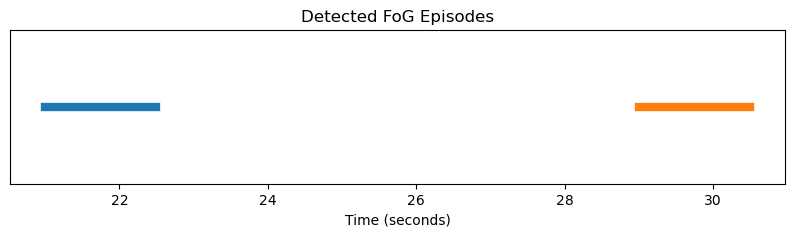

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
for _, ep in fog_episodes.iterrows():
    plt.plot([ep.start_time, ep.end_time], [1,1], linewidth=6)

plt.yticks([])
plt.xlabel("Time (seconds)")
plt.title("Detected FoG Episodes")
plt.show()
